In [1]:
import numpy as np, pandas as pd

df = pd.read_csv("datasets/auto-mpg.csv")

In [2]:
#drive.mount('/content/drive/MyDrive/TC2004_B/PCA/')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [3]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [4]:
non_numeric_hp = df[~df['horsepower'].str.replace('.','', 1).str.isnumeric()]['horsepower'].unique()
print("Non-numeric horsepower values:", non_numeric_hp)

Non-numeric horsepower values: <StringArray>
['?']
Length: 1, dtype: str


In [5]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])

In [6]:
df.isnull().sum() #checking missing values after replacing

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [13]:
df['horsepower'] = df['horsepower'].fillna(mean_hp)

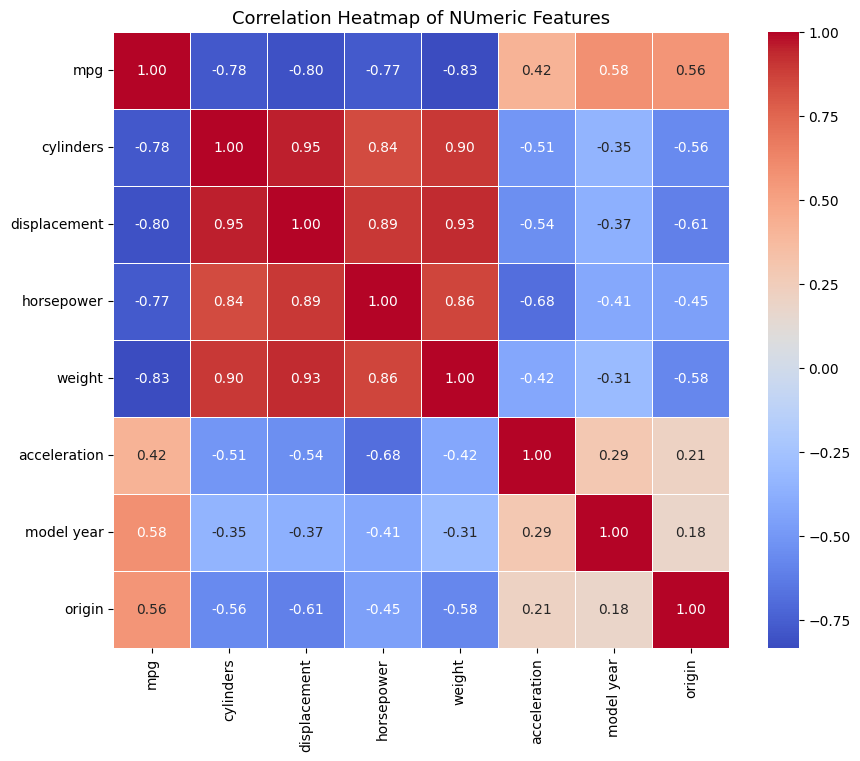

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['float64', 'int64']).corr() #exludes car name
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title('Correlation Heatmap of NUmeric Features', fontsize=13)
plt.show()

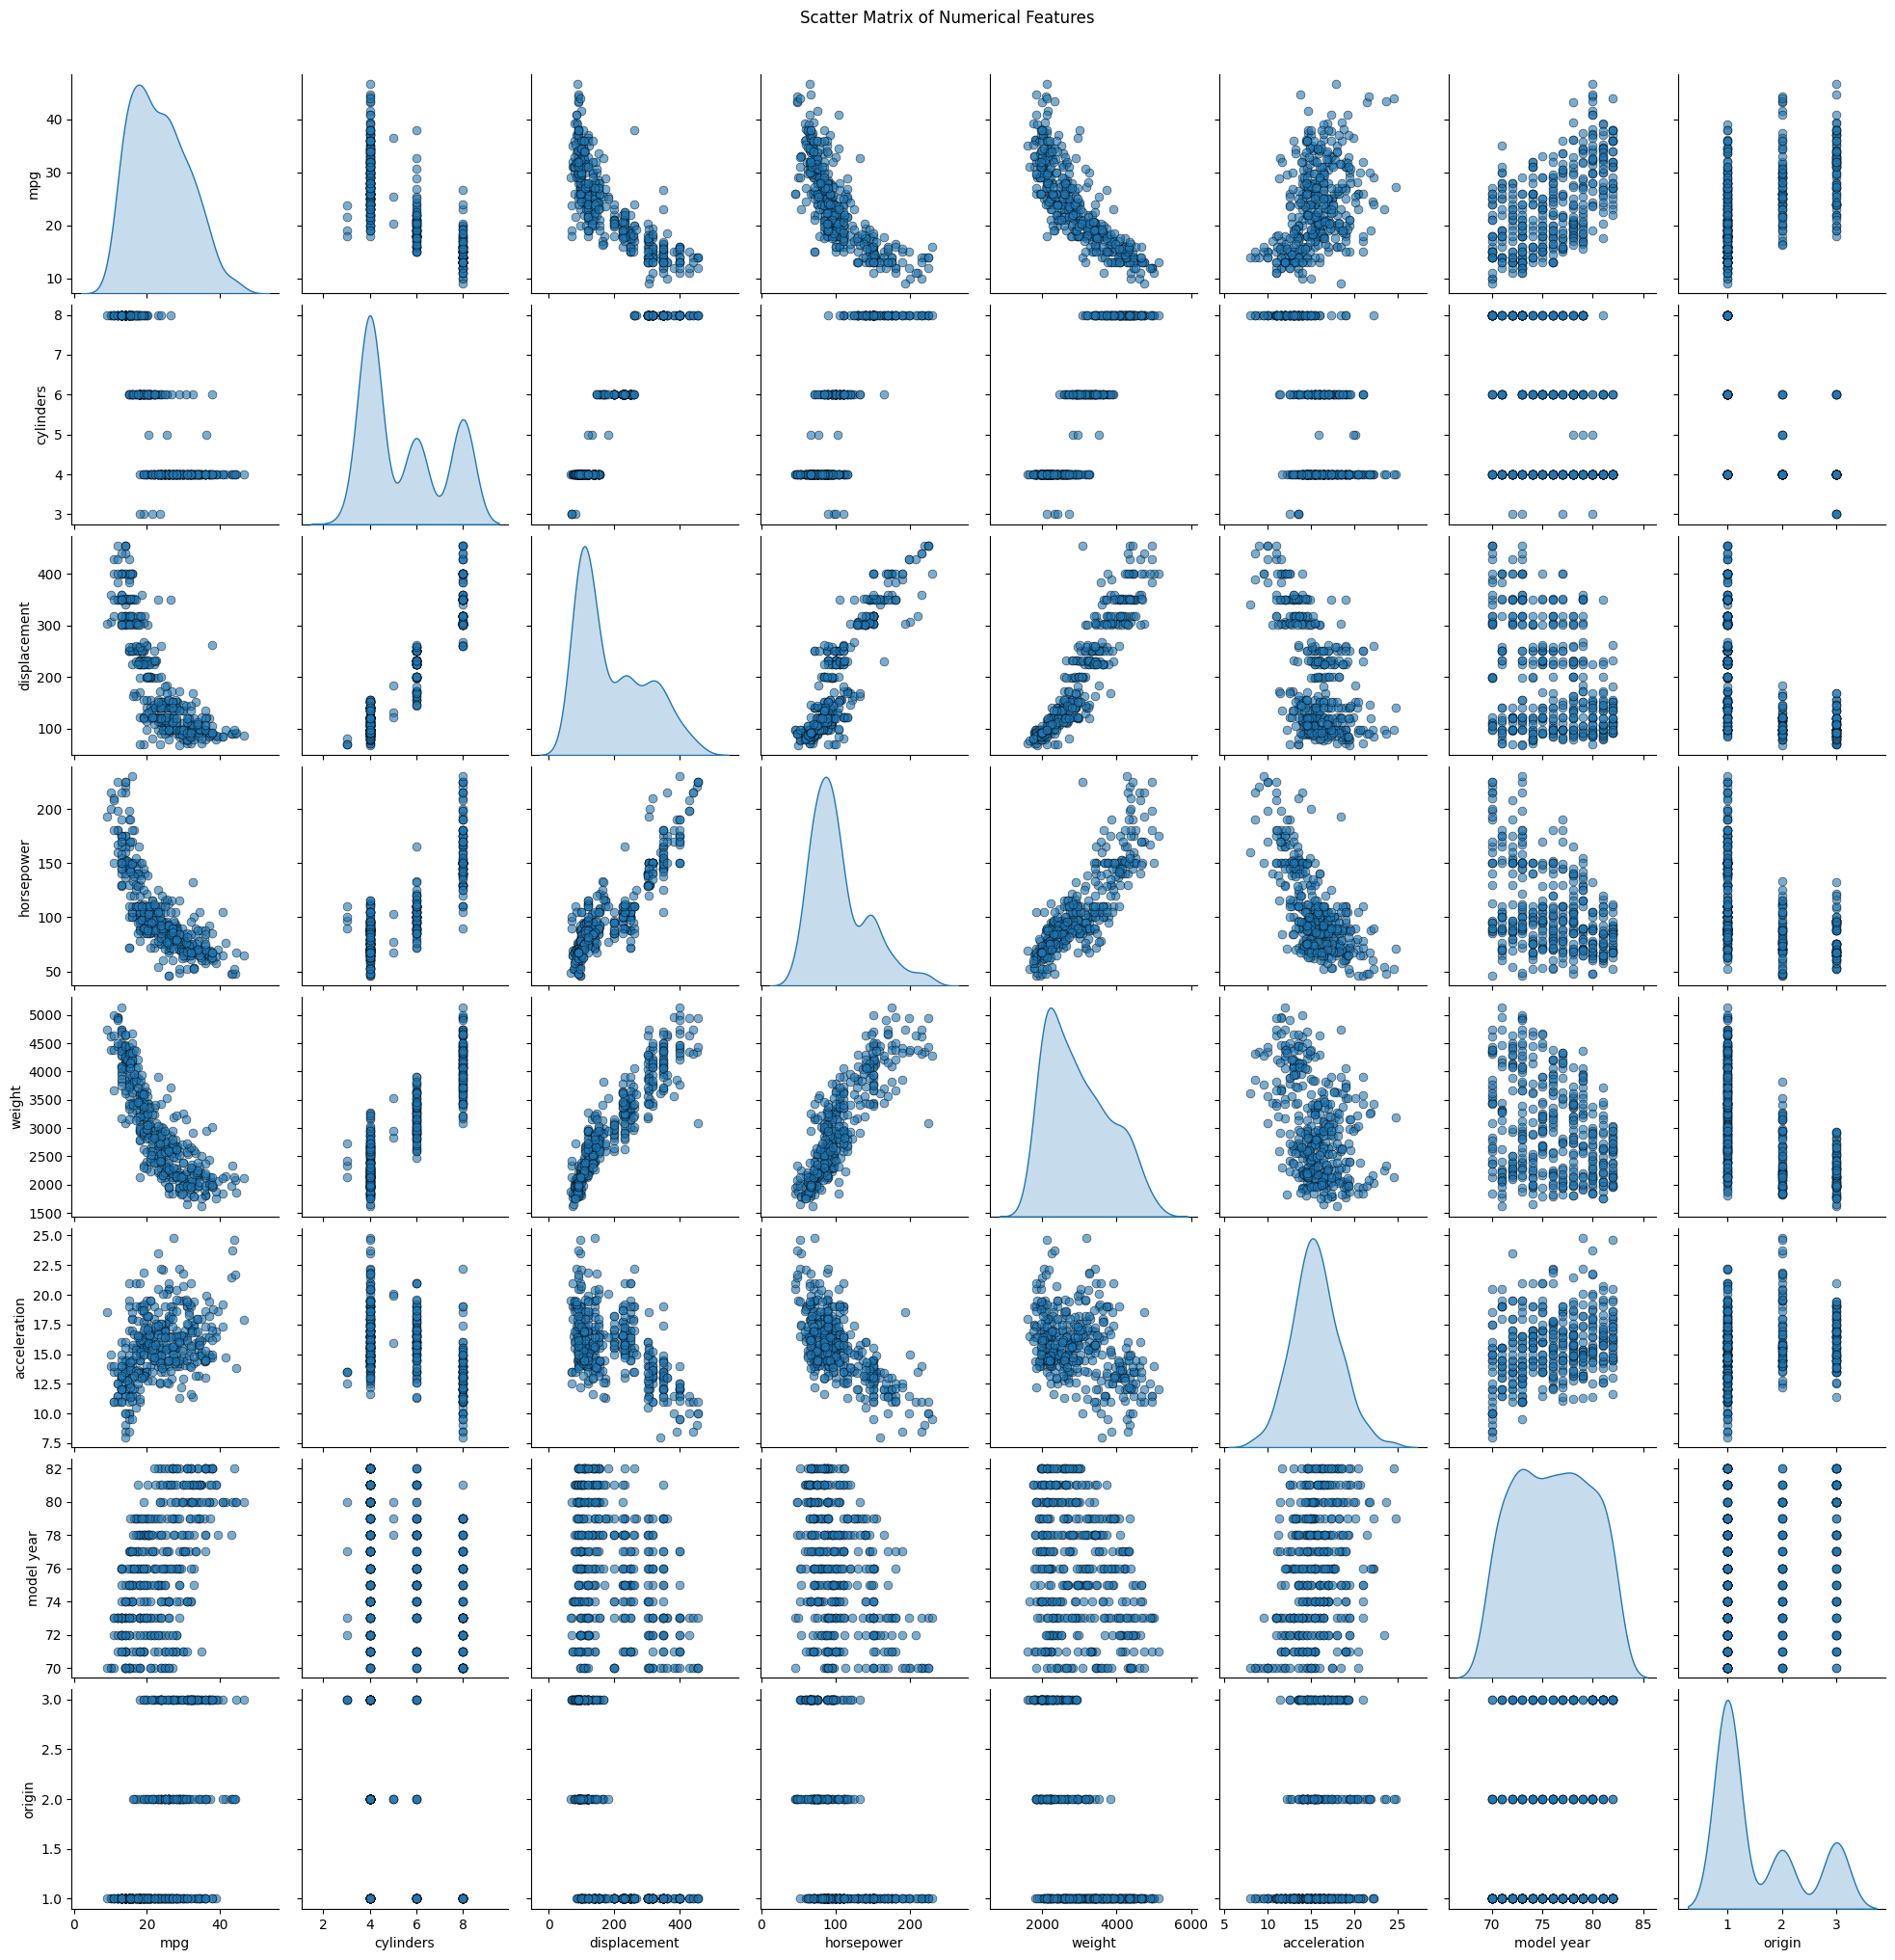

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.pairplot(numeric_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's':40, 'edgecolor':'k'})

plt.suptitle("Scatter Matrix of Numerical Features", y=1.02)
plt.show()

In [16]:
import pandas as pd

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df.drop(columns=['car name', 'origin']) #Dropped because they're categorical

X = add_constant(X)

X = X.dropna()

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,const,757.031966
1,mpg,5.227504
2,cylinders,10.604849
3,displacement,19.765922
4,horsepower,8.644376
5,weight,13.429119
6,acceleration,2.510462
7,model year,1.910226


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

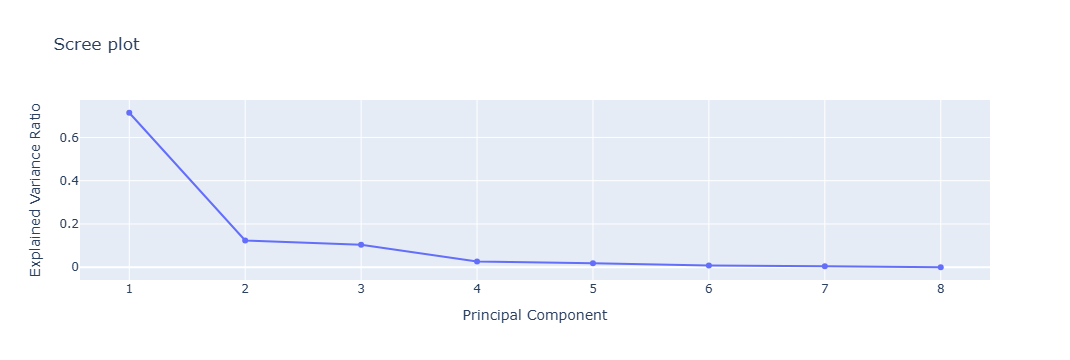

Explained Variance per Principal Component


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.7142,0.7142
1,PC2,0.1237,0.8379
2,PC3,0.1041,0.9420
3,PC4,0.0267,0.9687
4,PC5,0.0182,0.9869
5,PC6,0.0081,0.9950
6,PC7,0.0050,1.0000
7,PC8,0.0000,1.0000


Principal Component Loadings


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
const,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,1.0
mpg,-0.3979,0.2118,-0.2562,0.7477,0.3295,0.2356,-0.0898,0.0
cylinders,0.4166,0.1911,0.1409,0.4851,-0.4730,-0.3562,-0.4290,0.0
displacement,0.4299,0.1770,0.1037,0.2942,-0.0649,0.1465,0.8129,0.0
horsepower,0.4217,0.0918,-0.1680,-0.0393,0.7385,-0.4846,-0.0610,0.0
weight,0.4144,0.2215,0.2798,-0.1133,0.2264,0.7064,-0.3713,0.0
acceleration,-0.2848,-0.0245,0.8927,0.1262,0.2432,-0.2084,0.0534,0.0
model year,-0.2294,0.9106,-0.0172,-0.2980,-0.0877,-0.1371,0.0508,0.0


In [25]:
# Interactive graph
import plotly.express as px

#Prepare data

components = list(range(1, len(pca.explained_variance_ratio_)+1))
variance_ratio = pca.explained_variance_ratio_

#Create interactive line chart
fig = px.line(
    x=components,
    y=variance_ratio,
    markers=True,
    labels = {'x': "Principal Component", 'y': 'Explained Variance Ratio'},
    title = 'Scree plot'
)
fig.show()

explained_variance = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

print("Explained Variance per Principal Component")
display(explained_variance.round(4))

loadings = pd.DataFrame(pca.components_.T, 
                        columns = [f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)
print("Principal Component Loadings")
display(loadings.round(4))

In [30]:
# Only keeping the first three:
X_pca_3 = X_pca[:, :3]

df_pca = pd.DataFrame(X_pca_3, columns=['PC1', 'PC2', 'PC3'])
df_pca

,PC1,PC2,PC3
0,2.660088,-0.919219,-0.559197
1,3.521679,-0.789385,-0.671600
2,2.996660,-0.861310,-0.982945
3,2.935927,-0.949077,-0.608106
4,2.929128,-0.931849,-1.079775
...,...,...,...
393,-1.422936,1.225087,-0.284198
394,-4.096867,1.278557,1.963547
395,-1.549408,1.253450,-1.904720
396,-2.024927,1.131461,0.611690


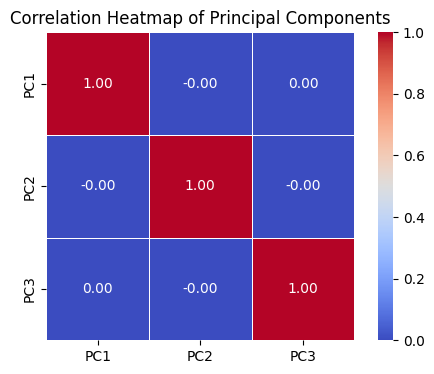

In [36]:
# Look at their no correlation

corr_pca = df_pca[['PC1', 'PC2', 'PC3']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_pca, annot=True, cmap='coolwarm', fmt='.2f', square = True, linewidth = 0.5)

plt.title("Correlation Heatmap of Principal Components")
#plt.show()

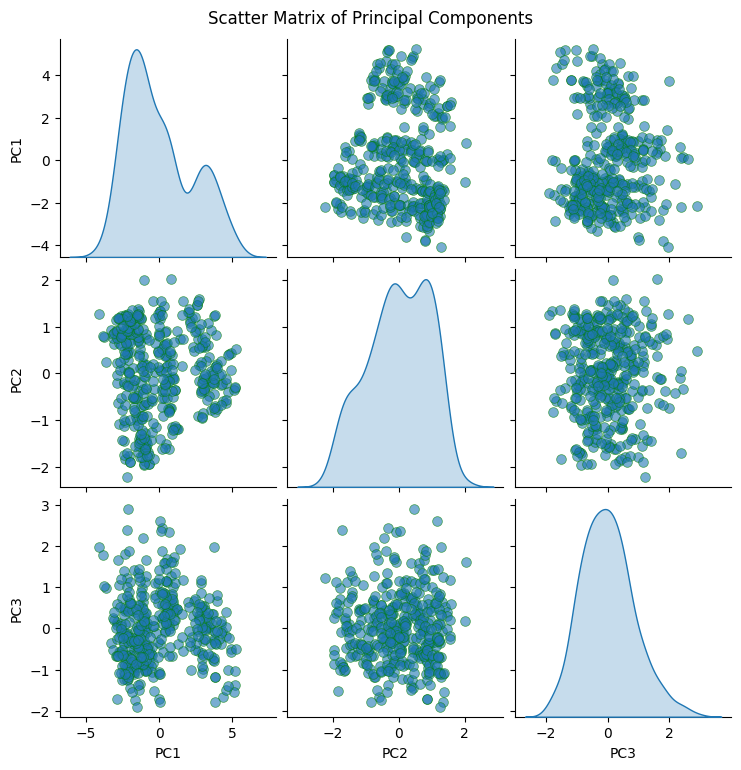

In [38]:
# Scatter Matrix

sns.pairplot(df_pca[['PC1', 'PC2', 'PC3']], diag_kind = 'kde', plot_kws={'alpha':0.6, 's': 49, 'edgecolor':'g'})
plt.suptitle("Scatter Matrix of Principal Components", y=1.02)
plt.show()

In [39]:
X = df_pca[['PC1', 'PC2', 'PC3']]

X = add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,const,1.0
1,PC1,1.0
2,PC2,1.0
3,PC3,1.0
